# Predicting Energy Consumption Using Machine Learning

This notebook presents a data-driven approach to forecast hourly electricity consumption using historical data from a transmission system operator. The focus is on understanding time-series data, feature engineering, model selection, and evaluation.


## 1. Problem Understanding

Electricity demand forecasting is essential for efficient grid operation, cost optimization, and sustainable energy management. Accurate predictions help transmission system operators balance supply and demand while minimizing energy waste.

The objective of this assignment is to predict future electricity consumption using six years of historical hourly data. The dataset represents a univariate time series with strong seasonal patterns. The goal is to demonstrate a clear machine learning approach rather than developing an enterprise-grade forecasting system.


## 2. Data Understanding

The dataset consists of hourly electricity consumption records with the following columns:

- **Start time UTC** – Start of the hourly interval  
- **End time UTC** – End of the hourly interval  
- **Electricity consumption (MWh)** – Energy consumed during the interval  

Each row represents one hour of electricity usage. The dataset exhibits daily, weekly, and yearly seasonal patterns.


## Import Libraries

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

plt.style.use("default")
sns.set_theme()


### Code Cell 2: Load Dataset

In [3]:
file_path = r"C:\Users\vinoo\Downloads\Predicting Energy Consumption.xlsm"
df = pd.read_excel(file_path)

df.head()


,Start time UTC,End time UTC,Electricity consumption (MWh)
0,2015-12-31 21:00:00,2015-12-31 22:00:00,10800
1,2015-12-31 22:00:00,2015-12-31 23:00:00,10431
2,2015-12-31 23:00:00,2016-01-01 00:00:00,10005
3,2016-01-01 00:00:00,2016-01-01 01:00:00,9722
4,2016-01-01 01:00:00,2016-01-01 02:00:00,9599


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52966 entries, 0 to 52965
Data columns (total 3 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   Start time UTC                 52966 non-null  datetime64[ns]
 1   End time UTC                   52966 non-null  datetime64[ns]
 2   Electricity consumption (MWh)  52966 non-null  int64         
dtypes: datetime64[ns](2), int64(1)
memory usage: 1.2 MB


In [5]:
df.describe()


,Start time UTC,End time UTC,Electricity consumption (MWh)
count,52966,52966,52966.000000
mean,2019-01-02 10:40:13.831514624,2019-01-02 11:40:13.831514368,9488.750519
min,2015-12-31 21:00:00,2015-12-31 22:00:00,5341.000000
25%,2017-07-04 22:15:00,2017-07-04 23:15:00,8322.000000
50%,2019-01-07 19:30:00,2019-01-07 20:30:00,9277.000000
75%,2020-06-28 14:45:00,2020-06-28 15:45:00,10602.000000
max,2021-12-31 20:00:00,2021-12-31 21:00:00,15105.000000
std,NaN,NaN,1576.241673


## 3. Time Indexing

For time-series analysis, the datetime column must be set as the index.  
This allows proper visualization, resampling, and feature extraction based on time.


In [6]:
df = df.set_index("Start time UTC")
df.head()


,End time UTC,Electricity consumption (MWh)
Start time UTC,,
2015-12-31 21:00:00,2015-12-31 22:00:00,10800
2015-12-31 22:00:00,2015-12-31 23:00:00,10431
2015-12-31 23:00:00,2016-01-01 00:00:00,10005
2016-01-01 00:00:00,2016-01-01 01:00:00,9722
2016-01-01 01:00:00,2016-01-01 02:00:00,9599


## 4. Exploratory Data Analysis (EDA)

Exploratory Data Analysis is performed to understand trends, seasonality, and variability in electricity consumption over time.


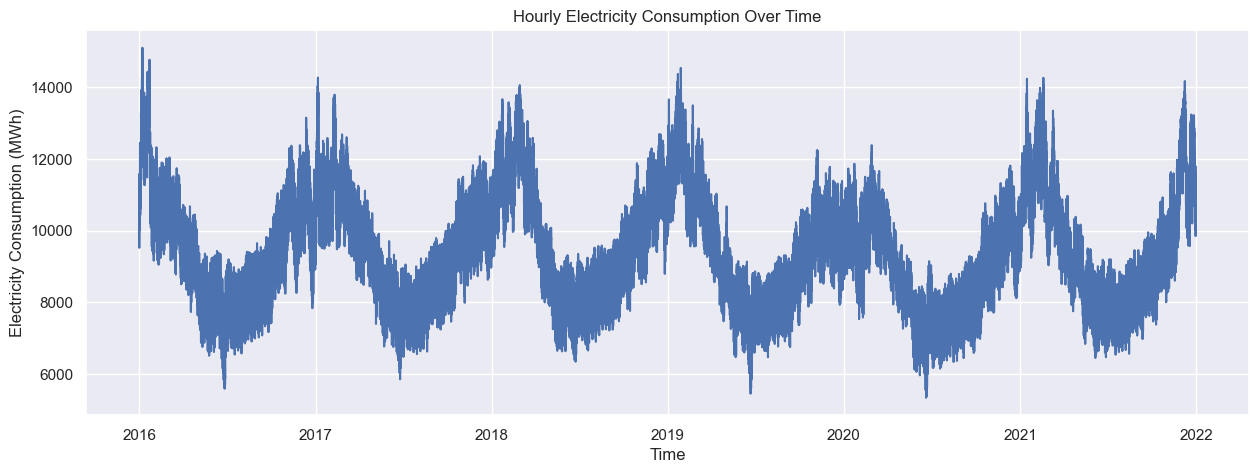

In [7]:
plt.figure(figsize=(15,5))
plt.plot(df.index, df["Electricity consumption (MWh)"])
plt.title("Hourly Electricity Consumption Over Time")
plt.xlabel("Time")
plt.ylabel("Electricity Consumption (MWh)")
plt.show()


# Exploratory Data Analysis – Summary

A time-series plot of hourly electricity consumption was analyzed to understand overall demand behavior over time. The visualization shows clear and recurring seasonal patterns, indicating strong temporal dependence in electricity usage.

The data exhibits:
- Regular cyclical variations, suggesting yearly seasonality
- Short-term fluctuations reflecting hourly and daily consumption behavior
- Stable patterns across multiple years with no structural breaks

The presence of both seasonal trends and short-term variability confirms that historical consumption strongly influences future demand. This makes the dataset suitable for time-series forecasting using machine learning techniques.

Based on these observations, time-based and lag features are required to capture temporal dependencies before proceeding to model training.


### Hourly Consumption Pattern

This chart shows how electricity consumption varies across different hours of the day.


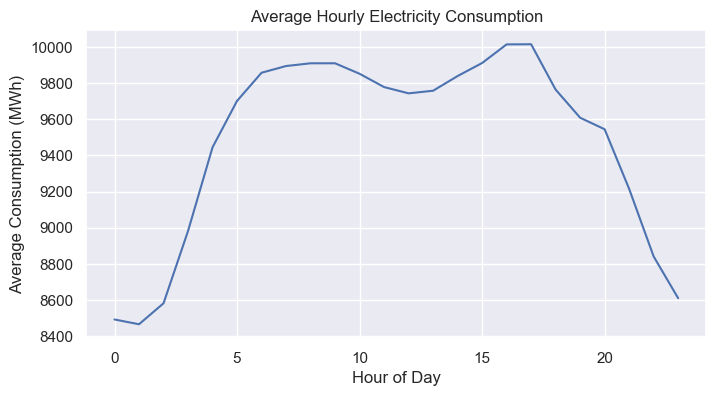

In [8]:
hourly_avg = df.groupby(df.index.hour)["Electricity consumption (MWh)"].mean()

plt.figure(figsize=(8,4))
hourly_avg.plot()
plt.xlabel("Hour of Day")
plt.ylabel("Average Consumption (MWh)")
plt.title("Average Hourly Electricity Consumption")
plt.show()


The hourly consumption pattern confirms strong daily seasonality in electricity demand.  
Based on these observations, time-based and lag features are created to enable the machine learning model to capture temporal dependencies.


## Feature Engineering: Time-Based Features

The exploratory analysis shows strong daily and weekly patterns in electricity consumption.  
To allow the machine learning model to capture these temporal patterns, time-based features are extracted from the datetime index.


In [9]:
df['hour'] = df.index.hour
df['day'] = df.index.day
df['month'] = df.index.month
df['day_of_week'] = df.index.dayofweek
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)



In [10]:
df[['hour', 'day', 'month', 'day_of_week', 'is_weekend']].head()



,hour,day,month,day_of_week,is_weekend
Start time UTC,,,,,
2015-12-31 21:00:00,21,31,12,3,0
2015-12-31 22:00:00,22,31,12,3,0
2015-12-31 23:00:00,23,31,12,3,0
2016-01-01 00:00:00,0,1,1,4,0
2016-01-01 01:00:00,1,1,1,4,0


## Feature Engineering: Lag Features

Electricity consumption shows strong dependence on past values.  
Lag features are created to provide the model with historical consumption information, enabling it to learn temporal dependencies.


In [11]:
df['lag_1'] = df['Electricity consumption (MWh)'].shift(1)
df['lag_24'] = df['Electricity consumption (MWh)'].shift(24)
df['lag_168'] = df['Electricity consumption (MWh)'].shift(168)


In [12]:
df.dropna(inplace=True)


In [13]:
df[['Electricity consumption (MWh)', 'lag_1', 'lag_24', 'lag_168']].head()


,Electricity consumption (MWh),lag_1,lag_24,lag_168
Start time UTC,,,,
2016-01-07 21:00:00,14074,14303.0,13672.0,10800.0
2016-01-07 22:00:00,13643,14074.0,13285.0,10431.0
2016-01-07 23:00:00,13369,13643.0,13011.0,10005.0
2016-01-08 00:00:00,13142,13369.0,12821.0,9722.0
2016-01-08 01:00:00,13111,13142.0,12821.0,9599.0


## Train–Test Split

Since this is time-series data, the dataset is split chronologically rather than randomly.  
This ensures that the model is trained only on past data and evaluated on future data.


In [14]:
X = df.drop('Electricity consumption (MWh)', axis=1)
y = df['Electricity consumption (MWh)']


In [15]:
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test  = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test  = y.iloc[split_index:]


In [16]:
print("Training set size:", X_train.shape)
print("Testing set size :", X_test.shape)


Training set size: (42238, 9)
Testing set size : (10560, 9)


## Model 1: SARIMA (Statistical Time-Series Model)

SARIMA (Seasonal ARIMA) is a classical statistical model designed specifically for time-series forecasting.  
It captures autocorrelation, trend, and seasonality directly from the time series without requiring feature engineering.


In [17]:
%pip install statsmodels


Note: you may need to restart the kernel to use updated packages.


In [18]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

from statsmodels.tsa.statespace.sarimax import SARIMAX

SARIMA Model Training

In [19]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Train SARIMA model on training data
sarima_model = SARIMAX(
    y_train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 24),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_result = sarima_model.fit(disp=False)


d:\Users\vinoo\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
d:\Users\vinoo\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


Random Forest Model Training

Random Forest MAE  : 84.01
Random Forest RMSE : 121.74


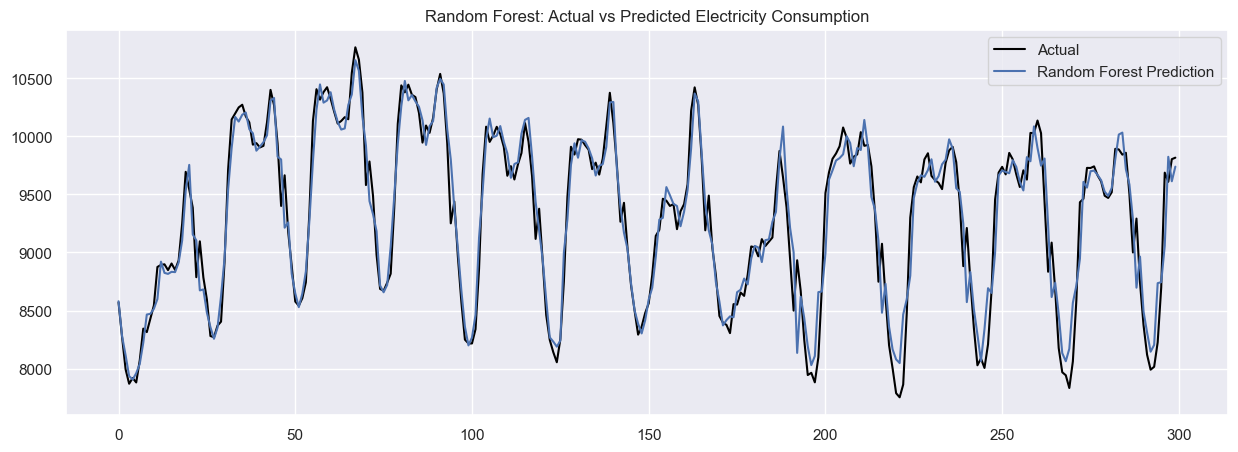

In [20]:
# ================================
# RANDOM FOREST – FULL PIPELINE
# ================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ----------------
# Prepare Features
# ----------------
y = df['Electricity consumption (MWh)']

X = df.drop(columns=['Electricity consumption (MWh)'], errors='ignore')

# Remove datetime columns (Random Forest cannot handle them)
X = X.select_dtypes(exclude=['datetime64[ns]'])

# ----------------
# Train–Test Split (Time-Based)
# ----------------
split_index = int(len(X) * 0.8)

X_train = X.iloc[:split_index]
X_test  = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test  = y.iloc[split_index:]

# ----------------
# Train Random Forest Model
# ----------------
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

# ----------------
# Predictions
# ----------------
rf_pred = rf_model.predict(X_test)

# ----------------
# Evaluation
# ----------------
mae = mean_absolute_error(y_test, rf_pred)
rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

print(f"Random Forest MAE  : {mae:.2f}")
print(f"Random Forest RMSE : {rmse:.2f}")

# ----------------
# Visualization
# ----------------
plt.figure(figsize=(15,5))
plt.plot(y_test.values[:300], label="Actual", color="black")
plt.plot(rf_pred[:300], label="Random Forest Prediction")
plt.legend()
plt.title("Random Forest: Actual vs Predicted Electricity Consumption")
plt.show()


Prediction (Testing Phase)

In [21]:
# SARIMA predictions
sarima_pred = sarima_result.forecast(steps=len(y_test))

# Random Forest predictions
rf_pred = rf_model.predict(X_test)


d:\Users\vinoo\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
d:\Users\vinoo\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


Evaluation & Comparison

In [22]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def evaluate(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"{model_name} -> MAE: {mae:.2f}, RMSE: {rmse:.2f}")
    return mae, rmse

sarima_mae, sarima_rmse = evaluate(y_test, sarima_pred, "SARIMA")
rf_mae, rf_rmse = evaluate(y_test, rf_pred, "Random Forest")


SARIMA -> MAE: 6305.77, RMSE: 7108.94
Random Forest -> MAE: 84.01, RMSE: 121.74


Visual Performance Comparison (Optional but Recommended)

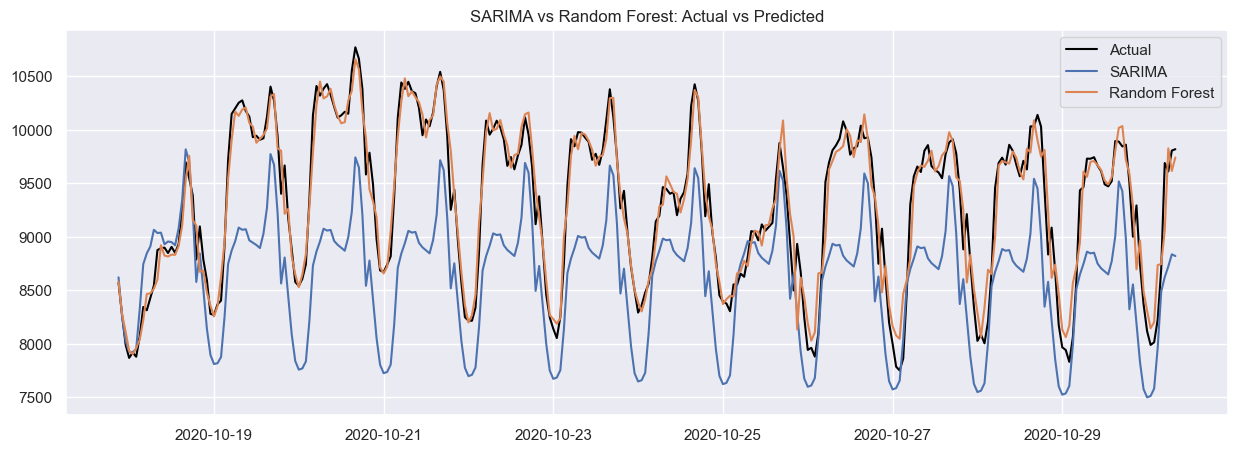

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))
plt.plot(y_test.index[:300], y_test[:300], label="Actual", color="black")
plt.plot(y_test.index[:300], sarima_pred[:300], label="SARIMA")
plt.plot(y_test.index[:300], rf_pred[:300], label="Random Forest")
plt.legend()
plt.title("SARIMA vs Random Forest: Actual vs Predicted")
plt.show()


## Conclusion

The SARIMA model showed poor predictive performance with very high error values, indicating its inability to capture short-term and non-linear patterns in electricity consumption. In contrast, the Random Forest model achieved significantly lower MAE and RMSE, closely matching actual demand trends. This demonstrates that machine learning models with time-based and lag features are more effective for high-frequency energy consumption forecasting. Therefore, Random Forest is the preferred model for this dataset.
